In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("churn.csv")

In [3]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [5]:
df.isna().any().sum()

np.int64(0)

In [8]:
df.Churn.value_counts()

Churn
0    2655
1     495
Name: count, dtype: int64

<Axes: xlabel='Churn'>

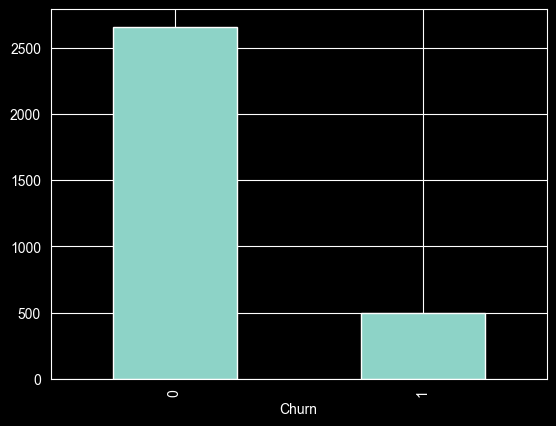

In [9]:
df.Churn.value_counts().plot(kind='bar')

In [10]:
 X = df.drop('Churn', axis=1)
 y = df['Churn']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
model.score(X_test, y_test)

from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       520
           1       0.73      0.42      0.53       110

    accuracy                           0.87       630
   macro avg       0.81      0.69      0.73       630
weighted avg       0.86      0.87      0.86       630



In [23]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
y_train_rus.value_counts()

Churn
0    385
1    385
Name: count, dtype: int64

In [24]:
model_rus = LogisticRegression(max_iter=10000)
model_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = model_rus.predict(X_test)
model_rus.score(X_test, y_test)

report_rus = classification_report(y_test, y_pred_rus)
print(report_rus)

              precision    recall  f1-score   support

           0       0.96      0.82      0.88       520
           1       0.49      0.82      0.62       110

    accuracy                           0.82       630
   macro avg       0.72      0.82      0.75       630
weighted avg       0.87      0.82      0.84       630



In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote.value_counts()
model_smote = LogisticRegression(max_iter=10000)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote= model_smote.predict(X_test)
model_smote.score(X_test, y_test)

report_smote = classification_report(y_test, y_pred_smote)
print(report_smote)

              precision    recall  f1-score   support

           0       0.95      0.80      0.87       520
           1       0.46      0.80      0.59       110

    accuracy                           0.80       630
   macro avg       0.71      0.80      0.73       630
weighted avg       0.86      0.80      0.82       630



In [26]:
from imblearn.combine import SMOTETomek

smoteTomek = SMOTETomek(random_state=42)
X_train_smoteTomek, y_train_smoteTomek = smoteTomek.fit_resample(X_train, y_train)
y_train_smoteTomek.value_counts()
model_smoteTomek = LogisticRegression(max_iter=10000)
model_smoteTomek.fit(X_train_smoteTomek, y_train_smoteTomek)
y_pred_smoteTomek= model_smoteTomek.predict(X_test)
model_smoteTomek.score(X_test, y_test)

report_smoteTomek = classification_report(y_test, y_pred_smoteTomek)
print(report_smoteTomek)

              precision    recall  f1-score   support

           0       0.95      0.80      0.87       520
           1       0.46      0.80      0.59       110

    accuracy                           0.80       630
   macro avg       0.71      0.80      0.73       630
weighted avg       0.86      0.80      0.82       630

